_Note: most of this code was generated using Gemini._

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from seaborn import set_style
from sklearn.metrics import mean_squared_error

set_style("whitegrid")

# River Data

## Playing Around with River Data

In [ ]:
outflow = pd.read_csv("../Data/FormattedData/DailyFlow_SaltDownstream.csv")

In [10]:
outflow.head()

,x,y,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-11,736.0,ft^3/s,Provisional,NaN,2026-06-12 09:05:13.660820+00:00
1,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-10,768.0,ft^3/s,Provisional,NaN,2026-06-11 09:05:18.362082+00:00
2,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-09,703.0,ft^3/s,Provisional,NaN,2026-06-10 09:05:02.080488+00:00
3,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-08,670.0,ft^3/s,Provisional,NaN,2026-06-09 09:05:04.440256+00:00
4,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-07,687.0,ft^3/s,Provisional,NaN,2026-06-08 09:05:05.149536+00:00


In [11]:
outflow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32031 entries, 0 to 32030
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   x                       32031 non-null  float64
 1   y                       32031 non-null  float64
 2   time_series_id          32031 non-null  object 
 3   monitoring_location_id  32031 non-null  object 
 4   parameter_code          32031 non-null  int64  
 5   statistic_id            32031 non-null  int64  
 6   time                    32031 non-null  object 
 7   value                   32031 non-null  float64
 8   unit_of_measure         32031 non-null  object 
 9   approval_status         32031 non-null  object 
 10  qualifier               218 non-null    object 
 11  last_modified           32031 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 2.9+ MB


In [13]:
pd.to_datetime(arg=outflow.time)

0       2026-06-11
1       2026-06-10
2       2026-06-09
3       2026-06-08
4       2026-06-07
           ...    
32026   1934-10-05
32027   1934-10-04
32028   1934-10-03
32029   1934-10-02
32030   1934-10-01
Name: time, Length: 32031, dtype: datetime64[ns]

In [15]:
outflow.time = pd.to_datetime(arg=outflow.time)

In [17]:
outflow.head()

,x,y,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
0,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-11,736.0,ft^3/s,Provisional,NaN,2026-06-12 09:05:13.660820+00:00
1,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-10,768.0,ft^3/s,Provisional,NaN,2026-06-11 09:05:18.362082+00:00
2,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-09,703.0,ft^3/s,Provisional,NaN,2026-06-10 09:05:02.080488+00:00
3,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-08,670.0,ft^3/s,Provisional,NaN,2026-06-09 09:05:04.440256+00:00
4,-111.576543,33.552841,2057fc3c33ce4e689bfa2c35d2c88387,USGS-09502000,60,3,2026-06-07,687.0,ft^3/s,Provisional,NaN,2026-06-08 09:05:05.149536+00:00


In [18]:
outflow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32031 entries, 0 to 32030
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   x                       32031 non-null  float64       
 1   y                       32031 non-null  float64       
 2   time_series_id          32031 non-null  object        
 3   monitoring_location_id  32031 non-null  object        
 4   parameter_code          32031 non-null  int64         
 5   statistic_id            32031 non-null  int64         
 6   time                    32031 non-null  datetime64[ns]
 7   value                   32031 non-null  float64       
 8   unit_of_measure         32031 non-null  object        
 9   approval_status         32031 non-null  object        
 10  qualifier               218 non-null    object        
 11  last_modified           32031 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), ob

## Editing Salt River Downstream Data File

### DailyFlow_SaltDownstream_Sorted.csv
In the following block, I create a new file where the Salt River downstream data is sorted by date, starting in 1934 and ending in 2026.

In [28]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_SaltDownstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically by the date
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean ISO strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Save the sorted and formatted dataset to a new CSV file
# index=False ensures we don't save an unnecessary index row column
df_sorted.to_csv("../Data/FormattedData/Havi/DailyFlow_SaltDownstream_Sorted.csv", index=False)

print("File successfully sorted and saved!")

File successfully sorted and saved!


In the following block I'm checking the different values that show up in each column of the sorted data file.

In [45]:
# 1. Load the dataset
file_path = "../Data/FormattedData/Havi/DailyFlow_SaltDownstream_Sorted.csv"
df = pd.read_csv(file_path)
features = ['x','y','time_series_id','monitoring_location_id','parameter_code','statistic_id','unit_of_measure','approval_status','qualifier']
for feature in features:
    print("The unique values of ",feature," are: ",df[feature].unique())

The unique values of  x  are:  [-111.57654306]
The unique values of  y  are:  [33.55284137]
The unique values of  time_series_id  are:  ['2057fc3c33ce4e689bfa2c35d2c88387']
The unique values of  monitoring_location_id  are:  ['USGS-09502000']
The unique values of  parameter_code  are:  [60]
The unique values of  statistic_id  are:  [3]
The unique values of  unit_of_measure  are:  ['ft^3/s']
The unique values of  approval_status  are:  ['Approved' 'Provisional']
The unique values of  qualifier  are:  [nan "['ESTIMATED']"]


### DailyFlow_SaltDownstream_Streamlined.csv

In the next code block, I'm making a new data file called 'DailyFlow_SaltDownstream_Streamlined.csv', which contains only 'time' and 'value' columns.

In [47]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_SaltDownstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects so it sorts properly
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically (oldest to newest)
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Filter the dataframe to only keep the 'time' and 'value' columns
df_final = df_sorted[["time", "value"]]

# 6. Save the streamlined dataset to a new CSV file
df_final.to_csv("../Data/FormattedData/Havi/DailyFlow_SaltDownstream_Streamlined.csv", index=False)

print("File successfully streamlined and saved!")

File successfully streamlined and saved!


### MonthlyFlow_SaltDownstream_Streamlined.csv
In the next code block, I create a new file 'MonthlyFlow_SaltDownstream_Streamlined.csv', which records the monthly average flow for each month.

In [52]:
import pandas as pd

# 1. Load the pre-sorted, two-column streamlined file
# parse_dates=['time'] automatically converts the column to datetime on import
file_path = "../Data/FormattedData/Havi/DailyFlow_SaltDownstream_Streamlined.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# 2. Set the 'time' column as the index (required for time-series resampling)
df.set_index("time", inplace=True)

# 3. Resample the data by Month Start ('MS') and calculate the mean
# This takes the daily 'value' points and groups them into monthly averages
monthly_df = df["value"].resample("MS").mean().reset_index()

# 4. Format the 'time' index back into clean text strings (YYYY-MM-DD)
monthly_df["time"] = monthly_df["time"].dt.strftime("%Y-%m-%d")

# 5. Save the final monthly averages out to a new file
monthly_df.to_csv("../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv", index=False)

print("Streamlined monthly file successfully created from the streamlined daily file!")

Streamlined monthly file successfully created from the streamlined daily file!


### salt_river_daily_flow.png
In the next code block, I plot the 'value' column of 'DailyFlow_SaltDownstream_Sorted.csv' against the 'time' column.

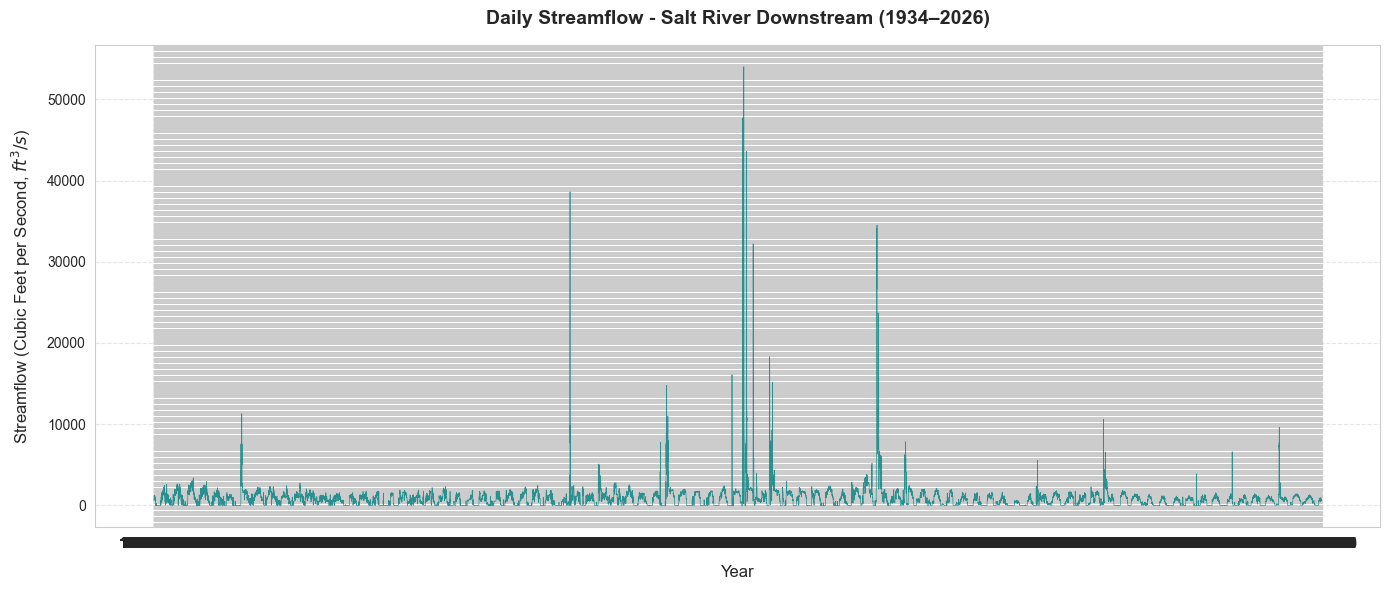

In [29]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
file_path = "../Data/FormattedData/Havi/DailyFlow_SaltDownstream_Sorted.csv"
df = pd.read_csv(file_path)

# 2. Convert the 'time' column to datetime objects
df["time"] = pd.to_datetime(df["time"])

# 3. CRITICAL: Sort by time so the line connects chronologically
# df_sorted = df.sort_values("time")

# 4. Initialize the plot layout (avoiding .figure())
fig, ax = plt.subplots(figsize=(14, 6))

# 5. Plot the streamflow timeline
# Using a thin line (linewidth=0.5) keeps the long-term historical spikes legible
ax.plot(
    df_sorted["time"],
    df_sorted["value"],
    color="teal",
    linewidth=0.5,
    alpha=0.8,
)

# 6. Customize labels, titles, and gridlines
ax.set_title(
    "Daily Streamflow - Salt River Downstream (1934–2026)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Streamflow (Cubic Feet per Second, $ft^3/s$)", fontsize=12, labelpad=10)
ax.grid(True, linestyle="--", alpha=0.5)

# 7. Prevent label truncation and save the image
plt.tight_layout()
plt.savefig("salt_river_daily_flow.png", dpi=300)

## Editing Salt River Upstream File

### DailyFlow_SaltUpstream_Sorted.csv
In the following block, I create a new file where the Salt River upstream data is sorted by date, starting in 1934 and ending in 2026.

In [56]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_SaltUpstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically by the date
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean ISO strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Save the sorted and formatted dataset to a new CSV file
# index=False ensures we don't save an unnecessary index row column
df_sorted.to_csv("../Data/FormattedData/Havi/DailyFlow_SaltUpstream_Sorted.csv", index=False)

print("File successfully sorted and saved!")

File successfully sorted and saved!


### DailyFlow_SaltUpstream_Streamlined.csv
In the next code block, I'm making a new data file called 'DailyFlow_SaltUpstream_Streamlined.csv', which contains only 'time' and 'value' columns.

In [57]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_SaltUpstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects so it sorts properly
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically (oldest to newest)
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Filter the dataframe to only keep the 'time' and 'value' columns
df_final = df_sorted[["time", "value"]]

# 6. Save the streamlined dataset to a new CSV file
df_final.to_csv("../Data/FormattedData/Havi/DailyFlow_SaltUpstream_Streamlined.csv", index=False)

print("File successfully streamlined and saved!")

File successfully streamlined and saved!


### MonthlyFlow_SaltUpstream_Streamlined.csv
In the next code block, I create a new file 'MonthlyFlow_SaltUpstream_Streamlined.csv', which records the monthly average flow for each month.

In [59]:
import pandas as pd

# 1. Load the pre-sorted, two-column streamlined file
# parse_dates=['time'] automatically converts the column to datetime on import
file_path = "../Data/FormattedData/Havi/DailyFlow_SaltUpstream_Streamlined.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# 2. Set the 'time' column as the index (required for time-series resampling)
df.set_index("time", inplace=True)

# 3. Resample the data by Month Start ('MS') and calculate the mean
# This takes the daily 'value' points and groups them into monthly averages
monthly_df = df["value"].resample("MS").mean().reset_index()

# 4. Format the 'time' index back into clean text strings (YYYY-MM-DD)
monthly_df["time"] = monthly_df["time"].dt.strftime("%Y-%m-%d")

# 5. Save the final monthly averages out to a new file
monthly_df.to_csv("../Data/FormattedData/Havi/MonthlyFlow_SaltUpstream_Streamlined.csv", index=False)

print("Streamlined monthly file successfully created from the streamlined daily file!")

Streamlined monthly file successfully created from the streamlined daily file!


## Editing Verde River Downstream Data

### DailyFlow_VerdeDownstream_Sorted.csv
In the following block, I create a new file where the Verde River downstream data is sorted by date, starting in 1934 and ending in 2026.

In [63]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_VerdeDownstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically by the date
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean ISO strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Save the sorted and formatted dataset to a new CSV file
# index=False ensures we don't save an unnecessary index row column
df_sorted.to_csv("../Data/FormattedData/Havi/DailyFlow_VerdeDownstream_Sorted.csv", index=False)

print("File successfully sorted and saved!")

File successfully sorted and saved!


### DailyFlow_VerdeDownstream_Streamlined.csv
In the next code block, I'm making a new data file called 'DailyFlow_VerdeDownstream_Streamlined.csv', which contains only 'time' and 'value' columns.

In [64]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_VerdeDownstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects so it sorts properly
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically (oldest to newest)
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Filter the dataframe to only keep the 'time' and 'value' columns
df_final = df_sorted[["time", "value"]]

# 6. Save the streamlined dataset to a new CSV file
df_final.to_csv("../Data/FormattedData/Havi/DailyFlow_VerdeDownstream_Streamlined.csv", index=False)

print("File successfully streamlined and saved!")

File successfully streamlined and saved!


### MonthlyFlow_VerdeDownstream_Streamlined.csv
In the next code block, I create a new file 'MonthlyFlow_VerdeDownstream_Streamlined.csv', which records the monthly average flow for each month.

In [65]:
import pandas as pd

# 1. Load the pre-sorted, two-column streamlined file
# parse_dates=['time'] automatically converts the column to datetime on import
file_path = "../Data/FormattedData/Havi/DailyFlow_VerdeDownstream_Streamlined.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# 2. Set the 'time' column as the index (required for time-series resampling)
df.set_index("time", inplace=True)

# 3. Resample the data by Month Start ('MS') and calculate the mean
# This takes the daily 'value' points and groups them into monthly averages
monthly_df = df["value"].resample("MS").mean().reset_index()

# 4. Format the 'time' index back into clean text strings (YYYY-MM-DD)
monthly_df["time"] = monthly_df["time"].dt.strftime("%Y-%m-%d")

# 5. Save the final monthly averages out to a new file
monthly_df.to_csv("../Data/FormattedData/Havi/MonthlyFlow_VerdeDownstream_Streamlined.csv", index=False)

print("Streamlined monthly file successfully created from the streamlined daily file!")

Streamlined monthly file successfully created from the streamlined daily file!


## Editing Verde River Upstream Data

### DailyFlow_VerdeUpstream_Sorted.csv 
In the following block, I create a new file where the Verde River upstream data is sorted by date, starting in 1934 and ending in 2026.

In [66]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_VerdeUpstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically by the date
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean ISO strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Save the sorted and formatted dataset to a new CSV file
# index=False ensures we don't save an unnecessary index row column
df_sorted.to_csv("../Data/FormattedData/Havi/DailyFlow_VerdeUpstream_Sorted.csv", index=False)

print("File successfully sorted and saved!")

File successfully sorted and saved!


### DailyFlow_VerdeUpstream_Streamlined.csv
In the next code block, I'm making a new data file called 'DailyFlow_VerdeUpstream_Streamlined.csv', which contains only 'time' and 'value' columns.

In [67]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/DailyFlow_VerdeUpstream.csv"
df = pd.read_csv(file_path)

# 2. Convert 'time' to actual datetime objects so it sorts properly
df["time"] = pd.to_datetime(df["time"])

# 3. Sort the rows chronologically (oldest to newest)
df_sorted = df.sort_values("time")

# 4. Format the datetime objects back to clean strings (YYYY-MM-DD)
df_sorted["time"] = df_sorted["time"].dt.strftime("%Y-%m-%d")

# 5. Filter the dataframe to only keep the 'time' and 'value' columns
df_final = df_sorted[["time", "value"]]

# 6. Save the streamlined dataset to a new CSV file
df_final.to_csv("../Data/FormattedData/Havi/DailyFlow_VerdeUpstream_Streamlined.csv", index=False)

print("File successfully streamlined and saved!")

File successfully streamlined and saved!


### MonthlyFlow_VerdeUpstream_Streamlined.csv
In the next code block, I create a new file 'MonthlyFlow_VerdeUpstream_Streamlined.csv', which records the monthly average flow for each month.

In [68]:
import pandas as pd

# 1. Load the pre-sorted, two-column streamlined file
# parse_dates=['time'] automatically converts the column to datetime on import
file_path = "../Data/FormattedData/Havi/DailyFlow_VerdeUpstream_Streamlined.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# 2. Set the 'time' column as the index (required for time-series resampling)
df.set_index("time", inplace=True)

# 3. Resample the data by Month Start ('MS') and calculate the mean
# This takes the daily 'value' points and groups them into monthly averages
monthly_df = df["value"].resample("MS").mean().reset_index()

# 4. Format the 'time' index back into clean text strings (YYYY-MM-DD)
monthly_df["time"] = monthly_df["time"].dt.strftime("%Y-%m-%d")

# 5. Save the final monthly averages out to a new file
monthly_df.to_csv("../Data/FormattedData/Havi/MonthlyFlow_VerdeUpstream_Streamlined.csv", index=False)

print("Streamlined monthly file successfully created from the streamlined daily file!")

Streamlined monthly file successfully created from the streamlined daily file!


# Climate Data

In [70]:
df = pd.read_csv("../Data/FormattedData/Climate_Watersheds.csv")
df.head()

,Time,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde
0,1895-01-01,2.016537,1.548778,71669.250,134251.9400
1,1895-02-01,2.488735,3.575411,17260.508,12643.4640
2,1895-03-01,5.915051,7.470766,4439.287,9704.5400
3,1895-04-01,9.875881,12.606539,2930.791,1849.8154
4,1895-05-01,14.626182,15.331393,10896.962,8430.8810


It seems like the climate data is already formatted conveniently.

# AMA Supply Data

In [72]:
df = pd.read_csv("../Data/RawData/AMA_Demand_Supply_from_DW.csv")
df

,YEAR,AMA,SECTOR,CATEGORY,PARENT WATER TYPE OR SECTOR,BUDGET ELEMENT,QUANTITY
0,1985,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,367146
1,1986,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,413154
2,1987,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,383850
3,1988,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,448694
4,1989,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,450473
5,1990,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,272083
6,1991,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,418856
7,1992,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,248811
8,1993,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,291624
9,1994,PHOENIX AMA,Agricultural,Supply,Surface Water,Surface Water,366067


### AMA_Demand_Supply_Streamlined.csv
In the next code block, I create a new file 'AMA_Demand_Supply_Streamlined.csv', that has only 'year'and 'quantity' columns.

In [ ]:
import pandas as pd

# 1. Load the original file
file_path = "../Data/RawData/AMA_Demand_Supply_from_DW.csv"
df = pd.read_csv(file_path)

# 2. Keep only the 'YEAR' and 'QUANTITY' columns and rename them to lowercase
df_streamlined = df[["YEAR", "QUANTITY"]].rename(
    columns={"YEAR": "year", "QUANTITY": "quantity"}
)

# 3. Save the streamlined dataset to a new CSV file
df_streamlined.to_csv("../Data/FormattedData/Havi/AMA_Demand_Supply_Streamlined.csv", index=False)

print("File successfully streamlined!")

File successfully streamlined!


### AMA_Demand_Supply_Monthly.csv
In the next code block, I am creating a new file 'AMA_Demand_Supply_Monthly.csv', which has monthly AMA supply data, where the monthly value is the same as the yearly value. 

In [ ]:
import pandas as pd

# 1. Load your streamlined yearly file
file_path = "../Data/FormattedData/Havi/AMA_Demand_Supply_Streamlined.csv"
df_ama = pd.read_csv(file_path)

# 2. Loop through each year and create 12 monthly entries
monthly_rows = []
for idx, row in df_ama.iterrows():
    year = int(row["year"])
    quantity = row["quantity"]

    # Generate a record for months 01 through 12
    for month in range(1, 13):
        # Format date as YYYY-MM-01 (e.g., 1985-01-01, 1985-02-01...)
        date_str = f"{year}-{month:02d}-01"
        monthly_rows.append({"time": date_str, "quantity": quantity})

# 3. Create a new DataFrame from the expanded rows
df_monthly_ama = pd.DataFrame(monthly_rows)

# 4. Ensure it is sorted chronologically
df_monthly_ama["time"] = pd.to_datetime(df_monthly_ama["time"])
df_monthly_ama = df_monthly_ama.sort_values("time")
df_monthly_ama["time"] = df_monthly_ama["time"].dt.strftime("%Y-%m-%d")

# 5. Save out the new expanded dataset to a CSV file
df_monthly_ama.to_csv("../Data/FormattedData/Havi/AMA_Demand_Supply_Monthly.csv", index=False)

print("Monthly file successfully created!")

Monthly file successfully created!


In [77]:
df1 = pd.read_csv("../Data/FormattedData/Havi/AMA_Demand_Supply_Monthly.csv")
df1.head(28)

,time,quantity
0,1985-01-01,367146
1,1985-02-01,367146
2,1985-03-01,367146
3,1985-04-01,367146
4,1985-05-01,367146
5,1985-06-01,367146
6,1985-07-01,367146
7,1985-08-01,367146
8,1985-09-01,367146
9,1985-10-01,367146


### Monthly_Divided_AMA_Supply.csv
In the next code block, I am creating a new file 'Monthly_Divided_AMA_Supply.csv', which has monthly AMA supply data, where the monthly value is the yearly value divided by 12.

In [6]:
import pandas as pd

# 1. Load the annual volume data
df_ama = pd.read_csv('../Data/FormattedData/Havi/AMA_Demand_Supply_Streamlined.csv')

monthly_records = []

# 2. Divide each known historical year by 12 across its months
for idx, row in df_ama.iterrows():
    year = int(row['year'])
    annual_qty = row['quantity']
    monthly_qty = annual_qty / 12.0
    
    for month in range(1, 13):
        date_str = f"{year}-{month:02d}-01"
        monthly_records.append({'time': date_str, 'quantity': monthly_qty})

# 3. Extrapolate forward into 2025 and mid-2026 using the last known stable volume (2024)
last_annual_qty = df_ama.iloc[-1]['quantity']
future_monthly_qty = last_annual_qty / 12.0

# 2025 Months
for month in range(1, 13):
    monthly_records.append({'time': f"2025-{month:02d}-01", 'quantity': future_monthly_qty})
# 2026 Months (through June)
for month in range(1, 7):
    monthly_records.append({'time': f"2026-{month:02d}-01", 'quantity': future_monthly_qty})

# 4. Final Format and Save
df_final = pd.DataFrame(monthly_records)
df_final['quantity'] = df_final['quantity'].round(0).astype(int)

# Save to your directory
df_final.to_csv('../Data/FormattedData/Havi/Monthly_Divided_AMA_Supply.csv', index=False)
print("Corrected flat monthly water supply matrix generated successfully!")

Corrected flat monthly water supply matrix generated successfully!


In [8]:
df_final.head(13)

,time,quantity
0,1985-01-01,30596
1,1985-02-01,30596
2,1985-03-01,30596
3,1985-04-01,30596
4,1985-05-01,30596
5,1985-06-01,30596
6,1985-07-01,30596
7,1985-08-01,30596
8,1985-09-01,30596
9,1985-10-01,30596


# Combining Data Into a Single File

### Combined_Arizona_Climate_Flow_Demand.csv
In the next block, I combine monthly AMA supply, monthly Salt River upstream and downstream flow, monthly Verde River upstream and downstream flow, monthly climate data for Maricopa county, and monthly climate data for the watershed of each river into a single file. The new file is called 'Combined_Arizona_Climate_Flow_Demand.csv'.

In [80]:
from functools import reduce
import pandas as pd

# 1. Load each dataset and assign distinct column labels to avoid ambiguity
df_ama = pd.read_csv("../Data/FormattedData/Havi/AMA_Demand_Supply_Monthly.csv").rename(
    columns={"quantity": "ama_quantity"}
)

df_salt_down = pd.read_csv("../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv").rename(
    columns={"value": "flow_salt_downstream"}
)
df_salt_up = pd.read_csv("../Data/FormattedData/Havi/MonthlyFlow_SaltUpstream_Streamlined.csv").rename(
    columns={"value": "flow_salt_upstream"}
)
df_verde_down = pd.read_csv("../Data/FormattedData/Havi/MonthlyFlow_VerdeDownstream_Streamlined.csv").rename(
    columns={"value": "flow_verde_downstream"}
)
df_verde_up = pd.read_csv("../Data/FormattedData/Havi/MonthlyFlow_VerdeUpstream_Streamlined.csv").rename(
    columns={"value": "flow_verde_upstream"}
)

df_maricopa = pd.read_csv("../Data/FormattedData/Climate_MaricopaCounty.csv").rename(
    columns={"Time": "time", "Temp": "temp_maricopa", "Precip": "precip_maricopa"}
)
df_watersheds = pd.read_csv("../Data/FormattedData/Climate_Watersheds.csv").rename(
    columns={"Time": "time"}
)

# 2. Gather all tables into an iterative array
dfs = [
    df_maricopa,
    df_watersheds,
    df_verde_down,
    df_salt_up,
    df_salt_down,
    df_verde_up,
    df_ama,
]

# 3. Standardize all time representations to a uniform string format (YYYY-MM-DD)
for df in dfs:
    df["time"] = pd.to_datetime(df["time"]).dt.strftime("%Y-%m-%d")

# 4. Successively merge all tables together using an Outer Join
df_merged = reduce(
    lambda left, right: pd.merge(left, right, on="time", how="outer"), dfs
)

# 5. Sort chronologically from past to present
df_merged = df_merged.sort_values("time").reset_index(drop=True)

# 6. Save the final multi-variable table to disk
df_merged.to_csv("../Data/FormattedData/Havi/Combined_Arizona_Climate_Flow_Demand.csv", index=False)

In [83]:
df1 = pd.read_csv("../Data/FormattedData/Havi/Combined_Arizona_Climate_Flow_Demand.csv")
df1.head(1000)

,time,temp_maricopa,precip_maricopa,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde,flow_verde_downstream,flow_salt_upstream,flow_salt_downstream,flow_verde_upstream,ama_quantity
0,1895-01-01,11.525407,74211.4840,2.016537,1.548778,71669.250,134251.9400,NaN,NaN,NaN,NaN,NaN
1,1895-02-01,13.477033,5563.9630,2.488735,3.575411,17260.508,12643.4640,NaN,NaN,NaN,NaN,NaN
2,1895-03-01,15.974886,1110.3701,5.915051,7.470766,4439.287,9704.5400,NaN,NaN,NaN,NaN,NaN
3,1895-04-01,20.032337,296.8828,9.875881,12.606539,2930.791,1849.8154,NaN,NaN,NaN,NaN,NaN
4,1895-05-01,23.890900,1550.4785,14.626182,15.331393,10896.962,8430.8810,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1977-12-01,13.638906,27782.1230,5.168725,5.875842,12114.037,22927.1640,343.548387,161.483871,0.454839,242.709677,NaN
996,1978-01-01,11.604033,101486.3900,3.057797,3.825321,65943.340,85730.7000,159.806452,257.838710,0.000000,624.000000,NaN
997,1978-02-01,12.822868,92452.6600,3.321747,4.395143,67719.810,79587.9500,138.785714,1837.035714,1.060714,2053.178571,NaN
998,1978-03-01,16.867018,102812.6300,7.671542,8.649427,94614.195,118247.9140,9023.548387,10386.451613,980.109677,10418.064516,NaN


### Combined_Log_MonthlyFlow.csv
In the next block, I'm creating a file, 'Combined_Log_MonthlyFlow.csv', which contains log(water flow + 1) for each of rivers' upstream and downstream water flow data.

In [2]:
import pandas as pd
import numpy as np

# 1. Define file paths/names
files = {
    'salt_downstream': '../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv',
    'salt_upstream': '../Data/FormattedData/Havi/MonthlyFlow_SaltUpstream_Streamlined.csv',
    'verde_downstream': '../Data/FormattedData/Havi/MonthlyFlow_VerdeDownstream_Streamlined.csv',
    'verde_upstream': '../Data/FormattedData/Havi/MonthlyFlow_VerdeUpstream_Streamlined.csv'
}

# 2. Load each dataset and immediately rename 'value' to indicate the station
df_sd = pd.read_csv(files['salt_downstream']).rename(columns={'value': 'salt_downstream'})
df_su = pd.read_csv(files['salt_upstream']).rename(columns={'value': 'salt_upstream'})
df_vd = pd.read_csv(files['verde_downstream']).rename(columns={'value': 'verde_downstream'})
df_vu = pd.read_csv(files['verde_upstream']).rename(columns={'value': 'verde_upstream'})

# 3. Ensure the 'time' column is converted to datetime objects for accurate alignment
for df in [df_sd, df_su, df_vd, df_vu]:
    df['time'] = pd.to_datetime(df['time'])

# 4. Sequentially merge the DataFrames using an outer join
# This aligns rows by date and expands the timeline to cover the earliest to latest dates.
df_combined = df_sd.merge(df_su, on='time', how='outer')
df_combined = df_combined.merge(df_vd, on='time', how='outer')
df_combined = df_combined.merge(df_vu, on='time', how='outer')

# 5. Sort the master matrix chronologically
df_combined = df_combined.sort_values('time').reset_index(drop=True)

# 6. Apply the log(value + 1) transformation
# np.log1p(x) mathematically computes log(x + 1). It handles 0.0 values perfectly
# by converting them to 0.0 (since log(1) = 0) and ignores NaN values natively.
streamflow_cols = ['salt_downstream', 'salt_upstream', 'verde_downstream', 'verde_upstream']
for col in streamflow_cols:
    df_combined[col] = np.log1p(df_combined[col])

# 7. Convert 'time' back to a clean string format (YYYY-MM-DD) for storage
df_combined['time'] = df_combined['time'].dt.strftime('%Y-%m-%d')

# 8. Save the combined matrix to a new CSV file
output_path = '../Data/FormattedData/Havi/Combined_Log_MonthlyFlow.csv'
df_combined.to_csv(output_path, index=False)

print(f"Successfully combined files into '{output_path}'!")
print(df_combined.head())

Successfully combined files into '../Data/FormattedData/Havi/Combined_Log_MonthlyFlow.csv'!
         time  salt_downstream  salt_upstream  verde_downstream  \
0  1904-01-01              NaN            NaN          5.471321   
1  1904-02-01              NaN            NaN          5.426316   
2  1904-03-01              NaN            NaN          5.220530   
3  1904-04-01              NaN            NaN          4.783595   
4  1904-05-01              NaN            NaN          4.846470   

   verde_upstream  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


### Combined_Monthly_System_Data.csv
In the next block I create a new file, 'Combined_Monthly_System_Data.csv', which combines the monthly river flow data with lags, monthly climate data, monthly AMA supply data, monthly linearly extrapolated population data, and monthly data center capacity data.

In [30]:
import pandas as pd

# 1. Load all independent monthly components
df_flows = pd.read_csv('../Data/FormattedData/Havi/Combined_Log_MonthlyFlow_Lags.csv')
df_supply = pd.read_csv('../Data/FormattedData/Havi/Monthly_Divided_AMA_Supply.csv')
df_pop = pd.read_csv('../Data/FormattedData/Havi/Monthly_Linear_Extrapolated_Population.csv')
df_dc = pd.read_csv('../Data/FormattedData/Havi/Monthly_Phoenix_DataCenter_Capacity.csv')

# Load new climate files
df_cli_maricopa = pd.read_csv('../Data/FormattedData/Climate_MaricopaCounty.csv')
df_cli_watersheds = pd.read_csv('../Data/FormattedData/Climate_Watersheds.csv')

# 2. Rename columns to avoid ambiguous or overlapping labels
df_supply = df_supply.rename(columns={'quantity': 'ama_water_supply'})
df_pop = df_pop.rename(columns={'Population': 'maricopa_population'})

# Harmonize climate features and fix uppercase 'Time' columns
df_cli_maricopa = df_cli_maricopa.rename(columns={
    'Time': 'time',
    'Temp': 'maricopa_temp',
    'Precip': 'maricopa_precip'
})
df_cli_watersheds = df_cli_watersheds.rename(columns={'Time': 'time'})

# 3. Explicitly parse dates to Datetime objects to eliminate string format mismatches
df_flows['time'] = pd.to_datetime(df_flows['time'])
df_supply['time'] = pd.to_datetime(df_supply['time'])
df_pop['time'] = pd.to_datetime(df_pop['time'])
df_dc['time'] = pd.to_datetime(df_dc['time'])
df_cli_maricopa['time'] = pd.to_datetime(df_cli_maricopa['time'])
df_cli_watersheds['time'] = pd.to_datetime(df_cli_watersheds['time'])

# 4. Successive full outer merges to preserve entire time horizons across all data matrices
df_combined = df_flows.merge(df_supply, on='time', how='outer')
df_combined = df_combined.merge(df_pop, on='time', how='outer')
df_combined = df_combined.merge(df_dc, on='time', how='outer')
df_combined = df_combined.merge(df_cli_maricopa, on='time', how='outer')
df_combined = df_combined.merge(df_cli_watersheds, on='time', how='outer')

# 5. Standardize and sort the timeline index chronologically
df_combined = df_combined.sort_values('time').reset_index(drop=True)
df_combined['time'] = df_combined['time'].dt.strftime('%Y-%m-%d')

# 6. Export to final master file
df_combined.to_csv('../Data/FormattedData/Havi/Combined_Monthly_System_Data.csv', index=False)
print("Master analytical file with integrated climate data compiled successfully!")

Master analytical file with integrated climate data compiled successfully!


In [31]:
df_combined.tail(100)

,time,salt_downstream,salt_upstream,verde_downstream,verde_upstream,salt_downstream_lag_1,salt_downstream_lag_2,salt_downstream_lag_3,salt_downstream_lag_4,salt_downstream_lag_5,...,verde_upstream_lag_12,ama_water_supply,maricopa_population,operational_mw_total,maricopa_temp,maricopa_precip,Temp_Salt,Temp_Verde,Precip_Salt,Precip_Verde
1478,2018-03-01,5.509738,5.231281,5.942274,5.357347,2.176293,2.169901,2.248129,1.988924,6.214271,...,7.273249,7438.0,4279658.0,365.0,16.988668,3954.826200,8.130605,8.383435,11138.22100,16511.61300
1479,2018-04-01,6.514169,5.032614,4.664571,4.906977,5.509738,2.176293,2.169901,2.248129,1.988924,...,5.254540,7438.0,4284779.0,365.0,22.750841,55.219727,13.544917,14.175838,959.91504,821.45703
1480,2018-05-01,6.856768,4.634353,4.788029,4.578462,6.514169,5.509738,2.176293,2.169901,2.248129,...,4.907661,7438.0,4289735.0,365.0,25.584606,964.809600,16.467180,16.791890,3616.97850,8963.60700
1481,2018-06-01,7.068030,4.290733,4.724848,4.264228,6.856768,6.514169,5.509738,2.176293,2.169901,...,4.392142,7438.0,4294856.0,365.0,30.608847,4888.782000,21.922089,22.481215,8877.43800,6441.54000
1482,2018-07-01,7.107082,5.005850,4.858561,5.123906,7.068030,6.856768,6.514169,5.509738,2.176293,...,5.175785,7438.0,4299812.0,365.0,33.256927,72086.940000,23.065712,24.840229,62521.41000,86341.84000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,2026-02-01,3.169085,5.414989,6.146559,6.104380,3.157824,4.183379,5.833533,6.001734,6.697569,...,5.391190,11792.0,4757727.0,1212.0,17.150984,12837.333000,7.715839,8.630342,23583.45900,29818.23000
1574,2026-03-01,4.846268,5.499809,6.365916,5.579730,3.169085,3.157824,4.183379,5.833533,6.001734,...,5.405724,11792.0,4762353.0,1212.0,23.317196,3099.919000,13.461802,14.712197,4911.48050,1429.81350
1575,2026-04-01,6.584331,4.978801,5.054333,4.940213,4.846268,3.169085,3.157824,4.183379,5.833533,...,5.035003,11792.0,4767474.0,1212.0,21.909725,665.554700,11.983159,12.465713,9620.14200,15625.98500
1576,2026-05-01,6.432525,4.576406,5.031913,4.667539,6.584331,4.846268,3.169085,3.157824,4.183379,...,4.778798,11792.0,4772430.0,1212.0,25.614475,902.954100,15.674928,16.804207,16171.97300,9862.74100


# Population Data

In the next code block, I am looking at the population data in Maricopa County, as given in the file 'Population_County.csv'.

In [7]:
import pandas as pd

df = pd.read_csv("../Data/RawData/Population_County.csv")
df[df.COUNTY=='Maricopa County']

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,A00AA1920,A00AA1930,A00AA1940,A00AA1950,A00AA1960,A00AA1970,A00AA1980,A00AA1990,A00AA2000,A00AA2010,A00AA2020
7,G0400130,Arizona,4,40,Maricopa County,13,130,89576.0,150970.0,186193.0,331770.0,663510.0,967522.0,1509052.0,2122101,3072149,3817117,4420568


### Maricopa_Historical_Population.csv
In the next code block, I am creating a file called 'Maricopa_Historical_Population.csv', which is a table of Maricopa County population every decade from 1920 to 2020.

In [6]:
import pandas as pd

# 1. Load the population dataset
file_path = '../Data/RawData/Population_County.csv'
df = pd.read_csv(file_path)

# 2. Filter the rows to isolate Maricopa County
# We use a string match or exact equality check to grab the right row
maricopa_row = df[df['COUNTY'] == 'Maricopa County'].iloc[0]

# 3. Define the census years available in the columns (1920 to 2020)
years = [1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

# 4. Extract the population values dynamically using the column naming pattern
maricopa_population = []
for year in years:
    column_name = f"A00AA{year}"
    population_value = maricopa_row[column_name]
    
    maricopa_population.append({
        "Year": year,
        "Population": int(population_value)
    })

# 5. Convert the extracted list of dictionaries back into a clean DataFrame
df_maricopa = pd.DataFrame(maricopa_population)

# 6. Display the final structured table
print("Historical Population for Maricopa County, Arizona:")
print(df_maricopa.to_string(index=False))

# Optional: Save this specific subset to a new standalone CSV file
df_maricopa.to_csv('../Data/FormattedData/Havi/Maricopa_Historical_Population.csv', index=False)
print("\nSub-table successfully exported to 'Maricopa_Historical_Population.csv'")

Historical Population for Maricopa County, Arizona:
 Year  Population
 1920       89576
 1930      150970
 1940      186193
 1950      331770
 1960      663510
 1970      967522
 1980     1509052
 1990     2122101
 2000     3072149
 2010     3817117
 2020     4420568

Sub-table successfully exported to 'Maricopa_Historical_Population.csv'


### Maricopa_Monthly_Exponential_Population.csv
In the next code block, I'm exponentially extrapolating month-by-month population data for Maricopa county. This is put in a file called 'Maricopa_Monthly_Exponential_Population.csv'.

In [9]:
import pandas as pd
import numpy as np

def generate_exponential_timeline(input_csv, output_csv):
    # 1. Load the historical decennial population file
    df_hist = pd.read_csv(input_csv)
    
    # Map the census years to precise January 1st date anchors
    df_hist['Date'] = pd.to_datetime(df_hist['Year'].astype(str) + '-01-01')
    
    # 2. Build a full month-by-month index from January 1920 to May 2026
    # 'MS' stands for Month Start frequency (e.g., 1920-01-01, 1920-02-01...)
    date_range = pd.date_range(start='1920-01-01', end='2026-05-01', freq='MS')
    df_monthly = pd.DataFrame(index=date_range)
    df_monthly.index.name = 'time'
    
    # 3. Match the known decennial census numbers into their respective slots
    df_census_mapped = df_hist.set_index('Date')[['Population']]
    df_monthly = df_monthly.join(df_census_mapped)
    
    # 4. Perform Exponential Interpolation for the gaps between 1920 and 2020
    # To do this, we convert the population into log-space, use linear interpolation,
    # and then calculate the exponent to bring it back to a natural compounding curve.
    df_monthly['Log_Population'] = np.log(df_monthly['Population'])
    df_monthly['Log_Interpolated'] = df_monthly['Log_Population'].interpolate(method='linear')
    df_monthly['Exponential_Population'] = np.exp(df_monthly['Log_Interpolated'])
    
    # 5. Perform Exponential Extrapolation for post-2020 months (Feb 2020 to May 2026)
    # Extract the 2010 and 2020 populations to find the trailing decade compound growth rate
    pop_2010 = df_hist.loc[df_hist['Year'] == 2010, 'Population'].values[0]
    pop_2020 = df_hist.loc[df_hist['Year'] == 2020, 'Population'].values[0]
    months_in_decade = 120
    
    # Compounded Monthly Growth Rate (r)
    monthly_growth_rate = (pop_2020 / pop_2010) ** (1 / months_in_decade)
    
    # Isolate rows that come after the January 2020 census benchmark
    post_2020_mask = df_monthly.index > '2020-01-01'
    months_elapsed = np.arange(1, post_2020_mask.sum() + 1)
    
    # Apply the compound growth rate dynamically over time
    df_monthly.loc[post_2020_mask, 'Exponential_Population'] = pop_2020 * (monthly_growth_rate ** months_elapsed)
    
    # 6. Format the final timeline structure
    df_final = df_monthly.reset_index()[['time', 'Exponential_Population']]
    df_final['Exponential_Population'] = df_final['Exponential_Population'].astype(int)
    df_final['time'] = df_final['time'].dt.strftime('%Y-%m-%d')
    
    # 7. Output the matrix to a clean CSV file
    df_final.to_csv(output_csv, index=False)
    print(f"File successfully created: '{output_csv}' ({len(df_final)} rows)")

# Execute the code
generate_exponential_timeline(
    input_csv='../Data/FormattedData/Havi/Maricopa_Historical_Population.csv',
    output_csv='../Data/FormattedData/Havi/Maricopa_Monthly_Exponential_Population.csv'
)

File successfully created: '../Data/FormattedData/Havi/Maricopa_Monthly_Exponential_Population.csv' (1277 rows)


In [12]:
df1 = pd.read_csv('../Data/FormattedData/Havi/Maricopa_Monthly_Exponential_Population.csv')
df1.head(10)

,time,Exponential_Population
0,1920-01-01,89576
1,1920-02-01,89966
2,1920-03-01,90358
3,1920-04-01,90752
4,1920-05-01,91148
5,1920-06-01,91545
6,1920-07-01,91944
7,1920-08-01,92345
8,1920-09-01,92748
9,1920-10-01,93152


### Monthly_Linear_Extrapolated_Population.csv
In the next code block, I'm linearly extrapolating month-by-month population data for Maricopa county. This is put in a file called 'Monthly_Linear_Extrapolated_Population.csv'.

In [5]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# 1. Load the historical decadal population data
df_pop = pd.read_csv('../Data/FormattedData/Havi/Maricopa_Historical_Population.csv')

# 2. Treat the census year as a specific day (July 1st is standard for annual estimates)
df_pop['time'] = pd.to_datetime(df_pop['Year'].astype(str) + '-07-01')

# 3. Create a master monthly timeline covering the entire desired span
# Let's start from Jan 1920 and extend to June 2026 to match typical streamflow lengths
monthly_range = pd.date_range(start='1920-01-01', end='2026-06-01', freq='MS')
df_monthly = pd.DataFrame({'time': monthly_range})

# 4. Merge the known decade markers into our monthly timeline matrix
df_monthly = df_monthly.merge(df_pop[['time', 'Population']], on='time', how='left')

# 5. Convert timestamps into integers (nanoseconds since epoch) 
# This allows us to perform strict math operations based on the exact number of passing days
df_monthly['numeric_time'] = df_monthly['time'].astype(np.int64)

# 6. Separate rows where population is known to fit our mathematical line model
known_points = df_monthly[df_monthly['Population'].notnull()]

# 7. Build the interpolator/extrapolator function
# 'linear' means straight lines connect the dots.
# fill_value='extrapolate' uses the slope of the nearest boundary points to project outwards.
extrapolator = interp1d(
    known_points['numeric_time'], 
    known_points['Population'], 
    kind='linear', 
    fill_value='extrapolate'
)

# 8. Compute the values for every single month across the timeline
df_monthly['Population'] = extrapolator(df_monthly['numeric_time'])

# 9. Clean up: Round population to the nearest whole integer and drop numeric columns
df_monthly['Population'] = df_monthly['Population'].round(0).astype(int)
df_final = df_monthly[['time', 'Population']].copy()

# 10. Format time back to a standard date string for storage
df_final['time'] = df_final['time'].dt.strftime('%Y-%m-%d')

# 11. Save your completed monthly tracking file
df_final.to_csv('../Data/FormattedData/Havi/Monthly_Linear_Extrapolated_Population.csv', index=False)

print("Monthly population matrix generated successfully!")
print("\n--- Earliest Months (Extrapolated back to Jan 1920) ---")
print(df_final.head(12))
print("\n--- Latest Months (Extrapolated forward past 2020) ---")
print(df_final.tail(12))

Monthly population matrix generated successfully!

--- Earliest Months (Extrapolated back to Jan 1920) ---
          time  Population
0   1920-01-01       86516
1   1920-02-01       87038
2   1920-03-01       87525
3   1920-04-01       88046
4   1920-05-01       88551
5   1920-06-01       89072
6   1920-07-01       89576
7   1920-08-01       90097
8   1920-09-01       90618
9   1920-10-01       91123
10  1920-11-01       91644
11  1920-12-01       92148

--- Latest Months (Extrapolated forward past 2020) ---
            time  Population
1266  2025-07-01     4722211
1267  2025-08-01     4727332
1268  2025-09-01     4732453
1269  2025-10-01     4737409
1270  2025-11-01     4742530
1271  2025-12-01     4747485
1272  2026-01-01     4752606
1273  2026-02-01     4757727
1274  2026-03-01     4762353
1275  2026-04-01     4767474
1276  2026-05-01     4772430
1277  2026-06-01     4777551


# Data with Lags

### Combined_Log_MonthlyFlow_Lags.csv
In the next block I'm creating a file, 'Combined_Log_MonthlyFlow_Lags.csv', which has lags up to 12 months for each of the rivers' monthly upstream and downstream flow.

In [9]:
import pandas as pd

# 1. Load the combined monthly log streamflow dataset
df = pd.read_csv('../Data/FormattedData/Havi/Combined_Log_MonthlyFlow.csv')

# 2. Specify target river feature columns
river_cols = ['salt_downstream', 'salt_upstream', 'verde_downstream', 'verde_upstream']

# 3. Ensure proper chronological sequence before applying lag offsets
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# 4. Generate the lag permutations from 1 to 12 months
for col in river_cols:
    for lag in range(1, 13):
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# 5. Restore string date formatting and export
df['time'] = df['time'].dt.strftime('%Y-%m-%d')
df.to_csv('../Data/FormattedData/Havi/Combined_Log_MonthlyFlow_Lags.csv', index=False)

In [16]:
df[['verde_downstream','verde_downstream_lag_1','verde_downstream_lag_2','verde_downstream_lag_3','verde_downstream_lag_4']]

,verde_downstream,verde_downstream_lag_1,verde_downstream_lag_2,verde_downstream_lag_3,verde_downstream_lag_4
0,5.471321,NaN,NaN,NaN,NaN
1,5.426316,5.471321,NaN,NaN,NaN
2,5.220530,5.426316,5.471321,NaN,NaN
3,4.783595,5.220530,5.426316,5.471321,NaN
4,4.846470,4.783595,5.220530,5.426316,5.471321
...,...,...,...,...,...
1465,6.146559,5.940680,5.866102,4.905522,4.971380
1466,6.365916,6.146559,5.940680,5.866102,4.905522
1467,5.054333,6.365916,6.146559,5.940680,5.866102
1468,5.031913,5.054333,6.365916,6.146559,5.940680


# Data Centers

### phoenix_datacenters_streamlined.csv
In the next block I'm creating a new file, 'phoenix_datacenters_streamlined.csv', which has the year operational and MW capacity of each data center. 

In [ ]:
import pandas as pd

# Load the data center file
df = pd.read_csv('../Data/RawData/phoenix_datacenters_chronological.csv')

# Retain only the specified columns
df_stripped = df[['Initial_Operational_Year', 'Operational_MW_Capacity']]

# Export to a new CSV filephoenix_datacenters_streamlined.csv
df_stripped.to_csv('../Data/FormattedData/Havi/', index=False)

### Monthly_Phoenix_DataCenter_Capacity.csv
In the next block I create a new file, 'Monthly_Phoenix_DataCenter_Capacity.csv', which has monthly MW capacity for data centers.

In [18]:
import pandas as pd

# 1. Load the stripped data center dataset
df_stripped = pd.read_csv('../Data/FormattedData/Havi/phoenix_datacenters_streamlined.csv')

# 2. Build the matching monthly time horizon grid
months = pd.date_range(start='2012-01-01', end='2026-06-01', freq='MS')
df_monthly = pd.DataFrame({'time': months})

# 3. Calculate cumulative active operational MW capacity per month
def get_cumulative_operational(date):
    year = date.year
    active = df_stripped[df_stripped['Initial_Operational_Year'] <= year]
    return active['Operational_MW_Capacity'].sum()

df_monthly['operational_mw_total'] = df_monthly['time'].apply(get_cumulative_operational)

# 4. Final format clean-up and save
df_monthly['time'] = df_monthly['time'].dt.strftime('%Y-%m-%d')
df_monthly.to_csv('../Data/FormattedData/Havi/Monthly_Phoenix_DataCenter_Capacity.csv', index=False)

In [21]:
df_monthly.head(100)

,time,operational_mw_total
0,2012-01-01,54
1,2012-02-01,54
2,2012-03-01,54
3,2012-04-01,54
4,2012-05-01,54
...,...,...
95,2019-12-01,405
96,2020-01-01,573
97,2020-02-01,573
98,2020-03-01,573
